In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed datasets
df_2018 = pd.read_csv("regression_dataset_2018.csv")
df_2022 = pd.read_csv("regression_dataset_2022.csv")

# Add year column (important for analysis)
df_2018["year"] = 2018
df_2022["year"] = 2022

# Combine for EDA
df = pd.concat([df_2018, df_2022], ignore_index=True)

df.head()

,year,sex,employment_status,qualification_group,qualification_count_code,has_non_school_qualification,group_size_000,lowest_quintile_000,second_quintile_000,third_quintile_000,fourth_quintile_000,highest_quintile_000,avg_weekly_income,median_weekly_income,log_avg_weekly_income
0,2018,Female,Full-time,No_qualification,0,0,741.2,17.0,16.0,215.0,288.1,123.6,1142.1,1036.0,7.040624
1,2018,Female,Full-time,One,1,1,1333.0,19.6,27.5,254.6,463.4,403.4,1388.5,1247.0,7.235979
2,2018,Female,Full-time,Two,2,1,774.7,5.0,7.6,93.6,292.5,304.2,1584.0,1438.0,7.367709
3,2018,Female,Full-time,Three_or_more,3,1,320.5,4.1,5.8,29.7,92.9,164.8,1750.9,1592.0,7.467885
4,2018,Male,Full-time,No_qualification,0,0,1423.5,29.9,44.1,318.0,492.3,391.0,1304.1,1151.0,7.173268


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          32 non-null     int64  
 1   sex                           32 non-null     object 
 2   employment_status             32 non-null     object 
 3   qualification_group           32 non-null     object 
 4   qualification_count_code      32 non-null     int64  
 5   has_non_school_qualification  32 non-null     int64  
 6   group_size_000                32 non-null     float64
 7   lowest_quintile_000           32 non-null     float64
 8   second_quintile_000           32 non-null     float64
 9   third_quintile_000            32 non-null     float64
 10  fourth_quintile_000           32 non-null     float64
 11  highest_quintile_000          32 non-null     float64
 12  avg_weekly_income             32 non-null     float64
 13  median_

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


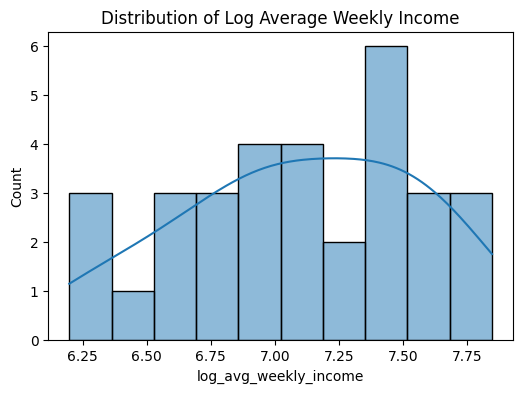

In [4]:
plt.figure(figsize=(6,4))
sns.histplot(df["log_avg_weekly_income"], kde=True, bins=10)
plt.title("Distribution of Log Average Weekly Income")
plt.show()

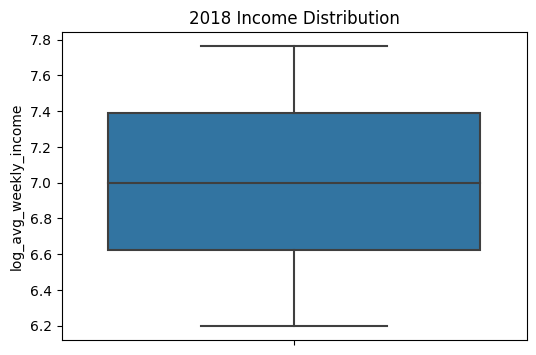

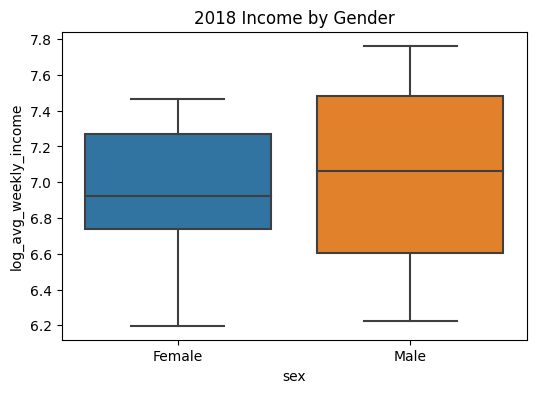

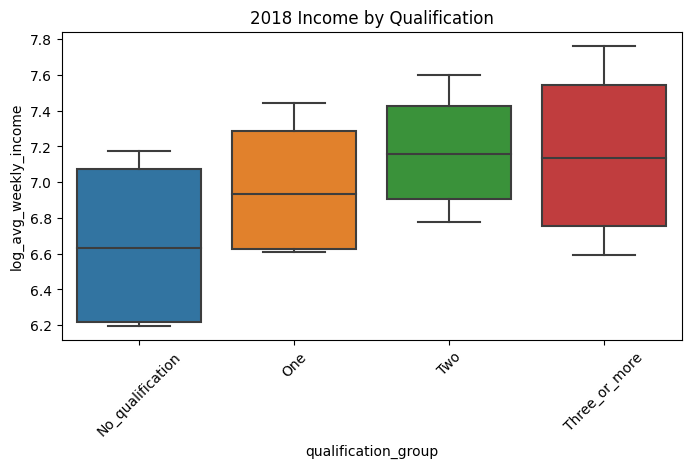

In [5]:
# 2018 ANALYSIS
df18 = df[df["year"] == 2018]

plt.figure(figsize=(6,4))
sns.boxplot(y="log_avg_weekly_income", data=df18)
plt.title("2018 Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="sex", y="log_avg_weekly_income", data=df18)
plt.title("2018 Income by Gender")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="qualification_group", y="log_avg_weekly_income", data=df18)
plt.title("2018 Income by Qualification")
plt.xticks(rotation=45)
plt.show()


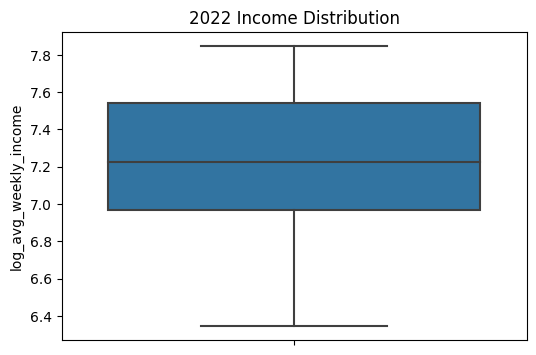

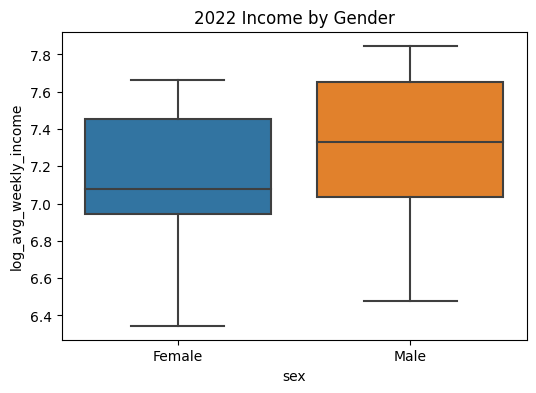

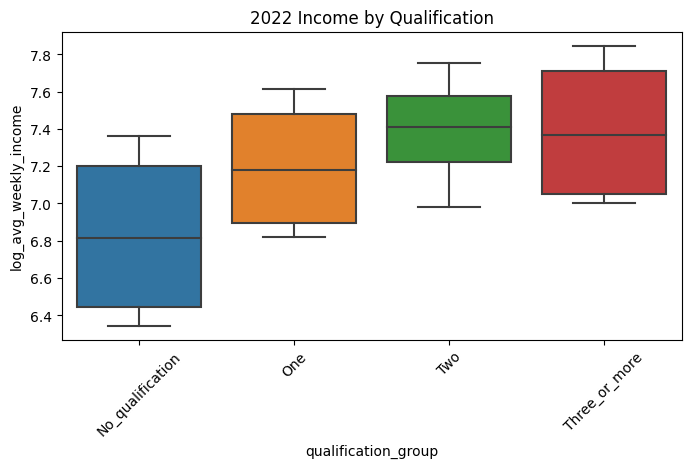

In [6]:
# 2022 ANALYSIS
df22 = df[df["year"] == 2022]

plt.figure(figsize=(6,4))
sns.boxplot(y="log_avg_weekly_income", data=df22)
plt.title("2022 Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="sex", y="log_avg_weekly_income", data=df22)
plt.title("2022 Income by Gender")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="qualification_group", y="log_avg_weekly_income", data=df22)
plt.title("2022 Income by Qualification")
plt.xticks(rotation=45)
plt.show()

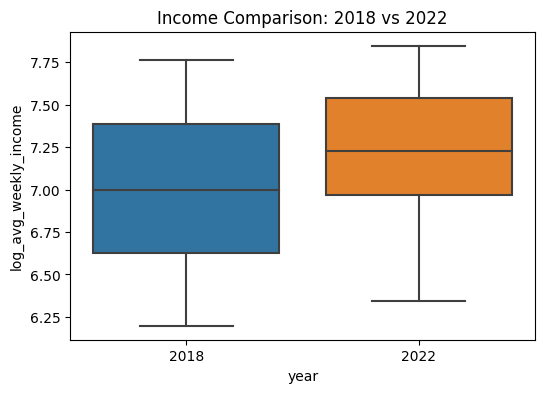

In [7]:

plt.figure(figsize=(6,4))
sns.boxplot(x="year", y="log_avg_weekly_income", data=df)
plt.title("Income Comparison: 2018 vs 2022")
plt.show()

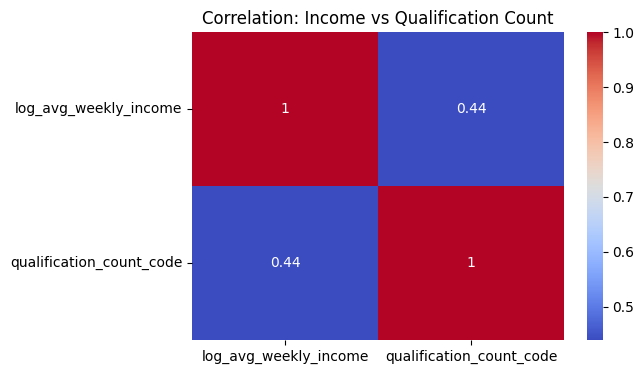

In [8]:
# CORRELATION
plt.figure(figsize=(6,4))
corr = df[["log_avg_weekly_income", "qualification_count_code"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation: Income vs Qualification Count")
plt.show()

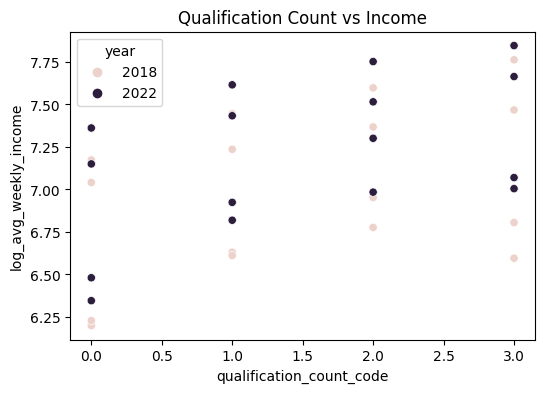

In [9]:
# SCATTER PLOT
plt.figure(figsize=(6,4))
sns.scatterplot(
    x="qualification_count_code",
    y="log_avg_weekly_income",
    data=df,
    hue="year"
)
plt.title("Qualification Count vs Income")
plt.show()